# Task 2 — Step 2: DAN — Multi-kernel MMD Alignment

DAN (Long et al., 2015) adds a discrepancy penalty between source and target representations at the 512-d feature before the classifier:
$$\mathcal{L}_{\text{DAN}}=\mathcal{L}_{\text{cls}}+\lambda_{\text{MMD}}\;\widehat{\text{MMD}}^2_k\big(F(x_s),F(x_t)\big),\qquad \lambda_{\text{MMD}}=1\ \text{(fixed)}$$
with the kernel trick
$$\widehat{\text{MMD}}^2_k=\tfrac{1}{n_s(n_s-1)}\textstyle\sum_{i\neq j} k(f^s_i,f^s_j)+\tfrac{1}{n_t(n_t-1)}\sum_{i\neq j} k(f^t_i,f^t_j)-\tfrac{2}{n_sn_t}\sum_{i,j} k(f^s_i,f^t_j),\quad k(a,b)=\sum_{m\in\{0.5,1,2\}}\exp\!\Big(-\frac{\|a-b\|^2}{2\,m\,\tilde d^2}\Big)$$
where $\tilde d^2$ is the **median pairwise squared distance in the current combined batch** (recomputed every step, treated as a constant).

This is the **unbiased** estimator (self-similarity terms $i=j$ excluded). The biased version has a positive floor even for identical distributions (≈0.10 at 24 vs 24, ≈0.30 at 8 vs 8), and minimising that floor rewards collapsing features. It broke DAN-DG in Task 3, which uses the same function.

The penalty is class-agnostic: it matches the marginal $P(F(X))$ and does not know which target example belongs to which class. $\lambda$ is held at 1 from the first step, as the manual specifies; there is no warm-up ramp.

In [1]:
%matplotlib inline
import os, sys, json, math
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, ROOT)

import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from shared.src.seed import set_seed, SEED
from shared.src.pacs_data import PACSDataset, get_pacs_dataloaders, PACS_SOURCE_DOMAINS, PACS_CLASSES
from shared.src.pacs_protocol import freeze_bn_stats, MAX_EPOCHS, PATIENCE
from shared.src.losses import compute_mmd
from shared.src.plotting import use_style, SEQ_CMAP, DIV_CMAP, PALETTE, DOMAIN_COLORS, NEUTRAL, INK_2, color_of, save_show
from task2_domain_adaptation.src.backbone import ResNet18Backbone
from task2_domain_adaptation.src.discriminator import DomainDiscriminator
from task2_domain_adaptation.src.train import train_uda, grl_alpha, cdan_features
from task2_domain_adaptation.src.evaluate import evaluate_source_validation, evaluate_target

use_style()
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA = os.path.join(ROOT, 'data', 'PACS')
SPLIT = os.path.join(ROOT, 'shared', 'splits', 'pacs_sketch_seed6304.json')
CKPT = os.path.join(ROOT, 'task2_domain_adaptation', 'checkpoints')
RES = os.path.join(ROOT, 'task2_domain_adaptation', 'results')
os.makedirs(CKPT, exist_ok=True); os.makedirs(RES, exist_ok=True)
print(f"device={device} | seed={SEED}")

device=cuda | seed=6304


## 1. Data
Each update: 8 labeled images from each source domain (24) + 24 **unlabeled** Sketch images. The target train loader yields `(image, label)` pairs because it wraps the same folder dataset, but the training loop discards the label (`x_t, _ = ...`).

In [2]:
src_train, src_val, tgt_train, tgt_eval = get_pacs_dataloaders(DATA, SPLIT, source_batch_size=8, target_batch_size=24, eval_batch_size=64)
print({d: len(l.dataset) for d, l in src_train.items()}, '| sketch (unlabeled):', len(tgt_train.dataset))
print('steps/epoch =', max(len(l) for l in src_train.values()), '(largest source domain; smaller loaders and the target loader are cycled)')

{'photo': 1336, 'art_painting': 1638, 'cartoon': 1875} | sketch (unlabeled): 3929
steps/epoch = 234 (largest source domain; smaller loaders and the target loader are cycled)


## 2. The kernel at initialisation
Real features from one source+target batch of the ImageNet-initialised network: the distribution of pairwise squared distances (normalised by the batch median) and the three RBF kernels evaluated on that axis.

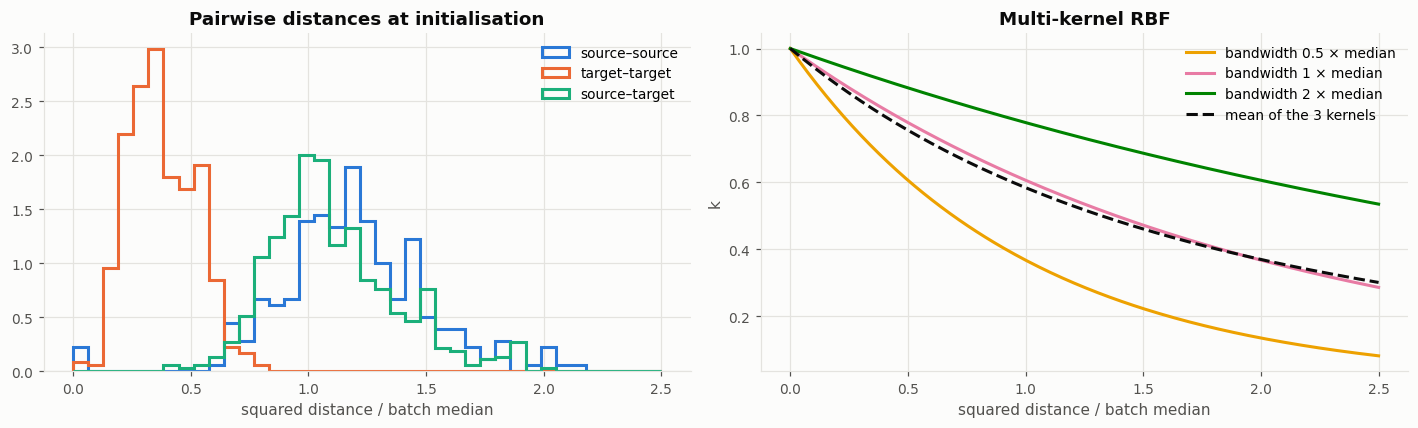

median squared distance 564.4 | MMD^2 at init 0.6666


In [3]:
set_seed(SEED)
m0 = ResNet18Backbone(num_classes=7).to(device).eval()
with torch.no_grad():
    xs = torch.cat([next(iter(src_train[d]))[0] for d in PACS_SOURCE_DOMAINS]).to(device)
    xt = next(iter(tgt_train))[0].to(device)
    fs, ft = m0(xs)[1], m0(xt)[1]
    fall = torch.cat([fs, ft]); d2 = torch.cdist(fall, fall).pow(2)
    med = d2[d2 > 0].median().item()
    mmd0 = compute_mmd(fs, ft).item()
n = fs.size(0)
ss, tt, st = d2[:n, :n], d2[n:, n:], d2[:n, n:]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
bins = np.linspace(0, 2.5, 40)
for block, lab, c in [(ss, 'source–source', DOMAIN_COLORS['source']), (tt, 'target–target', DOMAIN_COLORS['target']), (st, 'source–target', PALETTE[2])]:
    v = (block[block > 0] / med).cpu().numpy(); a1.hist(v, bins=bins, histtype='step', lw=2, color=c, label=lab, density=True)
a1.set_xlabel('squared distance / batch median'); a1.set_title('Pairwise distances at initialisation'); a1.legend()
r = np.linspace(0, 2.5, 200)
for m, c in zip([0.5, 1, 2], PALETTE[3:6]):
    a2.plot(r, np.exp(-r / (2 * m)), color=c, label=f'bandwidth {m} × median')
a2.plot(r, sum(np.exp(-r / (2 * m)) for m in [0.5, 1, 2]) / 3, color='#0b0b0b', ls='--', label='mean of the 3 kernels')
a2.set_xlabel('squared distance / batch median'); a2.set_ylabel('k'); a2.set_title('Multi-kernel RBF'); a2.legend()
fig.tight_layout(); save_show(fig, os.path.join(RES, 'dan_rbf_kernels.png'))
print(f"median squared distance {med:.1f} | MMD^2 at init {mmd0:.4f}")

## 3. Train DAN
Selection uses **only** mean source-validation macro-F1 (patience 5, ≤ 30 epochs (budget: `MAX_EPOCHS` / `PATIENCE` in `shared/src/pacs_protocol.py` = 30 / 5, as the manual specifies)). Set `FORCE_TRAIN = False` to reload.

In [4]:
FORCE_TRAIN = True
ckpt_path = os.path.join(CKPT, 'dan.pth')
hist_path = os.path.join(CKPT, 'dan_history.json')
CONFIG = dict(method='dan', lambda_mmd=1.0, lr=1e-4, wd=1e-4, max_epochs=MAX_EPOCHS, patience=PATIENCE, seed=SEED)
TRAIN_KW = {'method', 'lambda_mmd', 'lr', 'wd', 'max_epochs', 'patience'}

if FORCE_TRAIN or not os.path.exists(ckpt_path):
    set_seed(SEED)
    model = ResNet18Backbone(num_classes=7)
    out = train_uda(model, src_train, src_val, device, target_loader=tgt_train, save_path=ckpt_path, **{k: v for k, v in CONFIG.items() if k in TRAIN_KW})
    history, best_epoch, best_f1 = out['history'], out['best_epoch'], out['best_f1']
    json.dump({'config': CONFIG, 'history': history, 'best_epoch': best_epoch, 'best_f1': best_f1}, open(hist_path, 'w'), indent=1)
else:
    meta = json.load(open(hist_path)); history, best_epoch, best_f1 = meta['history'], meta['best_epoch'], meta['best_f1']
model = ResNet18Backbone(num_classes=7).to(device)
model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
print(f"selected epoch {best_epoch} | mean source-val macro-F1 {best_f1:.4f}")

[dan] ep  1 | cls 0.498 | mmd 0.053 | |f_s| 36.7 |f_t| 36.6 | tgt max-class 0.19 | val F1 0.9187 *
[dan] ep  2 | cls 0.201 | mmd 0.025 | |f_s| 39.7 |f_t| 39.9 | tgt max-class 0.19 | val F1 0.9041
[dan] ep  3 | cls 0.148 | mmd 0.018 | |f_s| 39.3 |f_t| 39.5 | tgt max-class 0.17 | val F1 0.9193 *
[dan] ep  4 | cls 0.083 | mmd 0.022 | |f_s| 41.4 |f_t| 41.5 | tgt max-class 0.17 | val F1 0.9237 *
[dan] ep  5 | cls 0.108 | mmd 0.010 | |f_s| 40.3 |f_t| 40.4 | tgt max-class 0.17 | val F1 0.9295 *
[dan] ep  6 | cls 0.056 | mmd 0.014 | |f_s| 41.8 |f_t| 42.2 | tgt max-class 0.17 | val F1 0.9361 *
[dan] ep  7 | cls 0.080 | mmd 0.016 | |f_s| 40.6 |f_t| 40.7 | tgt max-class 0.17 | val F1 0.9384 *
[dan] ep  8 | cls 0.042 | mmd 0.014 | |f_s| 38.8 |f_t| 38.9 | tgt max-class 0.16 | val F1 0.9350
[dan] ep  9 | cls 0.046 | mmd 0.009 | |f_s| 41.4 |f_t| 41.6 | tgt max-class 0.16 | val F1 0.9239
[dan] ep 10 | cls 0.042 | mmd 0.007 | |f_s| 42.9 |f_t| 43.0 | tgt max-class 0.17 | val F1 0.9120
[dan] ep 11 | cls 

## 4. Did DAN train as intended? (label-free diagnostics)
Top row: classification loss, the alignment term, and the weighted alignment term actually added to the loss. Bottom row: source-validation macro-F1 per domain, mean feature norm for source vs target batches, and the share of target images assigned to each class. A healthy adaptation run keeps the classification loss low, keeps source-validation F1 stable, narrows the feature-norm gap, and **does not** push most target images into one class. None of these panels use Sketch labels.

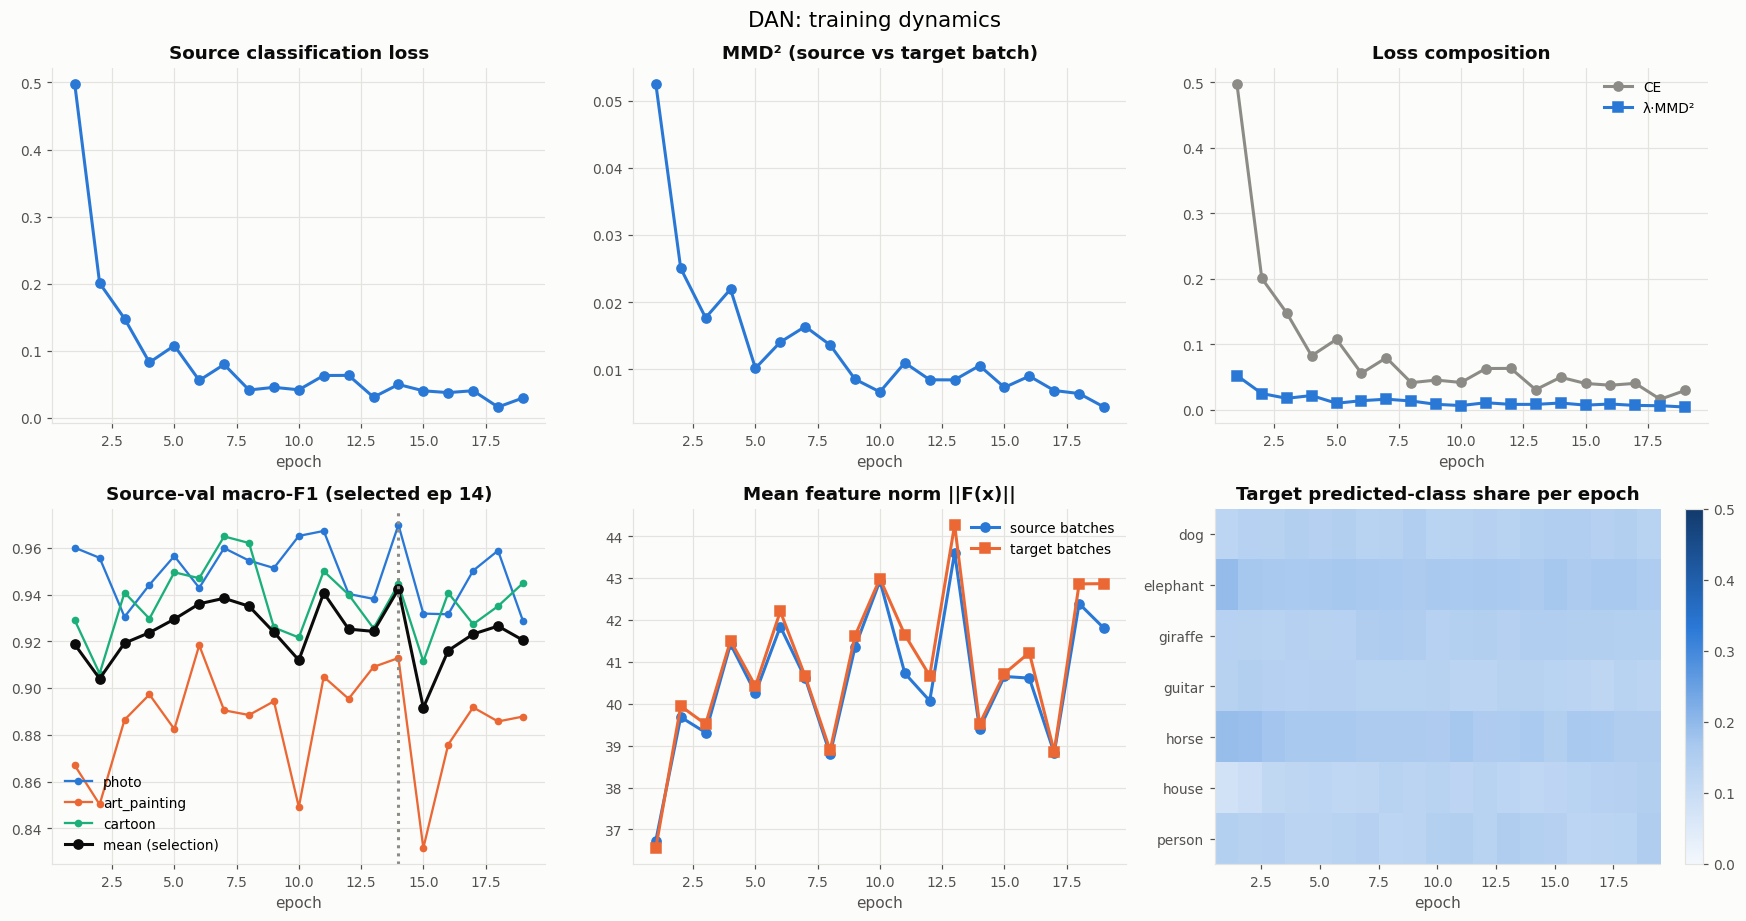

final-epoch target max-class share: 0.16 | at selected epoch: 0.16


In [5]:
H = history; ep = np.arange(1, len(H['cls_loss']) + 1)
fig, ax = plt.subplots(2, 3, figsize=(16, 8.5))
ax[0, 0].plot(ep, H['cls_loss'], 'o-', color=color_of('DAN'))
ax[0, 0].set_title('Source classification loss'); ax[0, 0].set_xlabel('epoch')
ax[0, 1].plot(ep, H['align_loss'], 'o-', color=color_of('DAN')); ax[0, 1].set_title('MMD² (source vs target batch)'); ax[0, 1].set_xlabel('epoch')
ax[0, 2].plot(ep, np.array(H['cls_loss']), 'o-', color=NEUTRAL, label='CE')
ax[0, 2].plot(ep, CONFIG['lambda_mmd'] * np.array(H['align_loss']), 's-', color=color_of('DAN'), label='λ·MMD²')
ax[0, 2].set_title('Loss composition'); ax[0, 2].legend(); ax[0, 2].set_xlabel('epoch')
for d in PACS_SOURCE_DOMAINS:
    ax[1, 0].plot(ep, H['val_per_domain'][d]['f1'], 'o-', ms=4, lw=1.5, color=DOMAIN_COLORS[d], label=d)
ax[1, 0].plot(ep, H['val_mean_f1'], 'o-', color='#0b0b0b', label='mean (selection)')
ax[1, 0].axvline(best_epoch, color=NEUTRAL, ls=':'); ax[1, 0].set_title(f'Source-val macro-F1 (selected ep {best_epoch})'); ax[1, 0].legend(); ax[1, 0].set_xlabel('epoch')
ax[1, 1].plot(ep, H['src_feat_norm'], 'o-', color=DOMAIN_COLORS['source'], label='source batches')
ax[1, 1].plot(ep, H['tgt_feat_norm'], 's-', color=DOMAIN_COLORS['target'], label='target batches')
ax[1, 1].set_title('Mean feature norm ||F(x)||'); ax[1, 1].legend(); ax[1, 1].set_xlabel('epoch')
share = np.array(H['tgt_pred_hist']).T
im = ax[1, 2].imshow(share, aspect='auto', cmap=SEQ_CMAP, vmin=0, vmax=max(0.5, share.max()), extent=[0.5, len(ep) + 0.5, 6.5, -0.5])
ax[1, 2].set_yticks(range(7)); ax[1, 2].set_yticklabels(PACS_CLASSES); ax[1, 2].grid(False)
ax[1, 2].set_title('Target predicted-class share per epoch'); ax[1, 2].set_xlabel('epoch'); fig.colorbar(im, ax=ax[1, 2], fraction=0.046)
fig.suptitle('DAN: training dynamics', fontsize=14); fig.tight_layout()
save_show(fig, os.path.join(RES, 'dan_training_curves.png'))
print(f"final-epoch target max-class share: {H['tgt_max_class_share'][-1]:.2f} | at selected epoch: {H['tgt_max_class_share'][best_epoch-1]:.2f}")

## 5. Source-validation results (locked checkpoint)

In [6]:
src_metrics = evaluate_source_validation(model, src_val, device)
tab = pd.DataFrame({d: {'acc (%)': 100 * src_metrics[d]['acc'], 'macro-F1 (%)': 100 * src_metrics[d]['f1']} for d in PACS_SOURCE_DOMAINS}).T
tab.loc['mean'] = [100 * src_metrics['mean_acc'], 100 * src_metrics['mean_f1']]
tab.loc['worst'] = tab.loc[PACS_SOURCE_DOMAINS].min()
tab.round(2)

,acc (%),macro-F1 (%)
photo,97.31,96.99
art_painting,91.22,91.29
cartoon,94.03,94.45
mean,94.18,94.24
worst,91.22,91.29


## 6. Target (Sketch) evaluation
Configuration and checkpoint are fixed above; Sketch labels are used here only to measure the result.

In [7]:
tgt = evaluate_target(model, tgt_eval, device)
so = pd.read_csv(os.path.join(RES, 'source_only_summary.csv'), index_col=0).iloc[0]
delta = 100 * (tgt['acc'] - so['Target (Sketch) Acc'])
print(f"Sketch acc {100*tgt['acc']:.2f}% | macro-F1 {100*tgt['f1']:.2f}% | change vs Source-only {delta:+.2f} pp")
summary = pd.DataFrame([{
    'Photo Val Acc': src_metrics['photo']['acc'], 'Art Val Acc': src_metrics['art_painting']['acc'], 'Cartoon Val Acc': src_metrics['cartoon']['acc'],
    'Photo Val F1': src_metrics['photo']['f1'], 'Art Val F1': src_metrics['art_painting']['f1'], 'Cartoon Val F1': src_metrics['cartoon']['f1'],
    'Mean Source Val Acc': src_metrics['mean_acc'], 'Mean Source Val F1': src_metrics['mean_f1'],
    'Target (Sketch) Acc': tgt['acc'], 'Target (Sketch) F1': tgt['f1'], 'Delta Target Acc': delta / 100}], index=['DAN'])
summary.to_csv(os.path.join(RES, 'dan_summary.csv'))
summary.T.round(4)

Sketch acc 65.49% | macro-F1 60.95% | change vs Source-only +6.26 pp


,DAN
Photo Val Acc,0.9731
Art Val Acc,0.9122
Cartoon Val Acc,0.9403
Photo Val F1,0.9699
Art Val F1,0.9129
Cartoon Val F1,0.9445
Mean Source Val Acc,0.9418
Mean Source Val F1,0.9424
Target (Sketch) Acc,0.6549
Target (Sketch) F1,0.6095


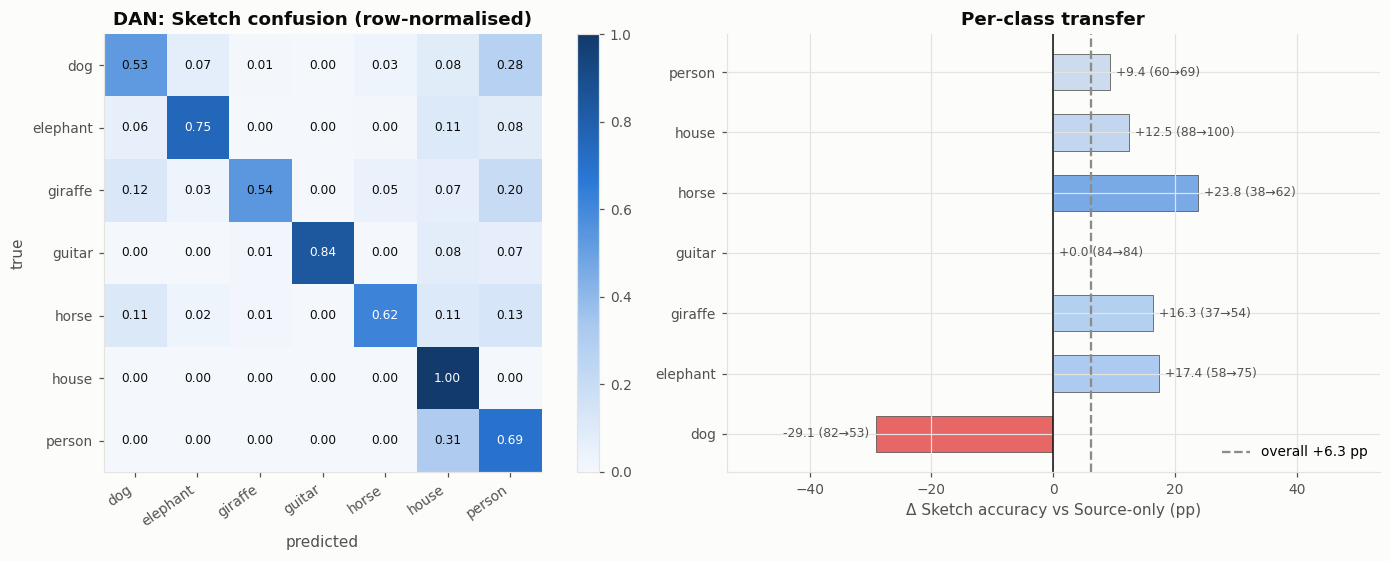

In [8]:
so_model = ResNet18Backbone(num_classes=7).to(device)
so_model.load_state_dict(torch.load(os.path.join(CKPT, 'source_only.pth'), map_location=device, weights_only=True))
so_tgt = evaluate_target(so_model, tgt_eval, device)
pc, pc_so = 100 * np.array(tgt['per_class_acc']), 100 * np.array(so_tgt['per_class_acc'])
dpc = pc - pc_so
cm = tgt['confusion_matrix']; cm_n = cm / cm.sum(1, keepdims=True)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={'width_ratios': [1.1, 1]})
im = a1.imshow(cm_n, cmap=SEQ_CMAP, vmin=0, vmax=1)
for i in range(7):
    for j in range(7):
        a1.text(j, i, f"{cm_n[i, j]:.2f}", ha='center', va='center', fontsize=8, color='white' if cm_n[i, j] > 0.55 else '#0b0b0b')
a1.set_xticks(range(7)); a1.set_xticklabels(PACS_CLASSES, rotation=35, ha='right'); a1.set_yticks(range(7)); a1.set_yticklabels(PACS_CLASSES)
a1.set_xlabel('predicted'); a1.set_ylabel('true'); a1.set_title('DAN: Sketch confusion (row-normalised)'); a1.grid(False)
fig.colorbar(im, ax=a1, fraction=0.046)
lim = max(5, np.abs(dpc).max() * 1.15)
cols = [DIV_CMAP(0.5 + 0.5 * v / lim) for v in dpc]
bars = a2.barh(PACS_CLASSES, dpc, color=cols, height=0.6, edgecolor='#52514e', linewidth=0.5)
a2.axvline(0, color='#0b0b0b', lw=1); a2.axvline(delta, color=NEUTRAL, ls='--', lw=1.5, label=f'overall {delta:+.1f} pp')
for b, v, s, t in zip(bars, dpc, pc_so, pc):
    a2.text(v + (1 if v >= 0 else -1), b.get_y() + b.get_height() / 2, f"{v:+.1f} ({s:.0f}→{t:.0f})", va='center', ha='left' if v >= 0 else 'right', fontsize=8, color=INK_2)
a2.set_xlim(-lim * 1.6, lim * 1.6); a2.set_xlabel('Δ Sketch accuracy vs Source-only (pp)'); a2.set_title('Per-class transfer'); a2.legend(loc='lower right')
fig.tight_layout()
save_show(fig, os.path.join(RES, 'dan_target_analysis.png'))